In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("C:\\Users\\Urvi Patel\\customer-intelligence-system\\data\\processed\\feature_engineered_telco.csv")

df.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,avg_charges,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1-2_year,tenure_group_2-4_year,tenure_group_4+_year
0,0,1,0,1,0,1,29.85,29.85,0,14.925000,...,False,False,False,False,False,True,False,False,False,False
1,0,0,0,34,1,0,56.95,1889.50,0,53.985714,...,False,False,True,False,False,False,True,False,True,False
2,0,0,0,2,1,1,53.85,108.15,1,36.050000,...,False,False,False,False,False,False,True,False,False,False
3,0,0,0,45,0,0,42.30,1840.75,0,40.016304,...,False,False,True,False,False,False,False,False,True,False
4,0,0,0,2,1,1,70.70,151.65,1,50.550000,...,False,False,False,False,False,True,False,False,False,False


In [3]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [4]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'avg_charges', 'num_services']

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [43]:
X = df.drop(['Churn', 'TotalCharges'], axis=1)

In [95]:
# =========================
# IMPORTS
# =========================
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score


# =========================
# 1. LOGISTIC REGRESSION (BASE MODEL)
# =========================
param_grid_lr = {
    'C': [0.1, 0.5, 1, 2],
    'class_weight': [
        {0:1, 1:1},
        {0:1, 1:1.5},
        {0:1, 1:2}
    ],
    'solver': ['lbfgs']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid_lr,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_

print("Best LR:", grid_lr.best_params_)
print("Best LR ROC-AUC:", grid_lr.best_score_)


# =========================
# 2. CREATE STACKED FEATURES
# =========================
train_probs_lr = best_lr.predict_proba(X_train)[:, 1]
test_probs_lr = best_lr.predict_proba(X_test)[:, 1]

X_train_stacked = X_train.copy()
X_test_stacked = X_test.copy()

X_train_stacked['lr_prob'] = train_probs_lr
X_test_stacked['lr_prob'] = test_probs_lr


# =========================
# 3. RANDOM FOREST (STACKED MODEL)
# =========================
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 8, 12],
    'min_samples_split': [2, 5, 10],
    'class_weight': [{0:1, 1:1.5}]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1
)

# 🔥 IMPORTANT: TRAIN ON STACKED DATA
grid_rf.fit(X_train_stacked, y_train)

best_rf = grid_rf.best_estimator_

print("Best RF:", grid_rf.best_params_)


# =========================
# 4. FINAL PREDICTIONS
# =========================
probs = best_rf.predict_proba(X_test_stacked)[:, 1]

# 🔥 tuned threshold
threshold = 0.4
preds = (probs >= threshold).astype(int)

Best LR: {'C': 2, 'class_weight': {0: 1, 1: 1.5}, 'solver': 'lbfgs'}
Best LR ROC-AUC: 0.8488784244495371
Best RF: {'class_weight': {0: 1, 1: 1.5}, 'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 300}


=== Classification Report ===

              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1033
           1       0.54      0.77      0.63       374

    accuracy                           0.76      1407
   macro avg       0.72      0.77      0.73      1407
weighted avg       0.80      0.76      0.77      1407


ROC-AUC: 0.8411938127358662

Precision: 0.536178107606679
Recall: 0.7727272727272727
F1 Score: 0.6330777656078861


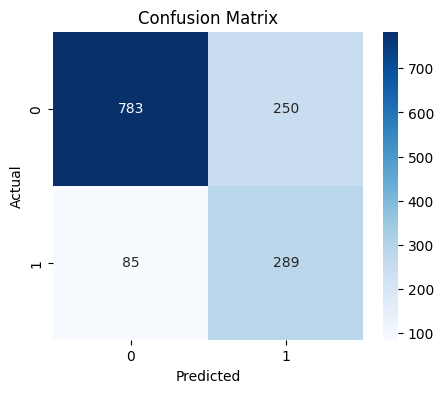

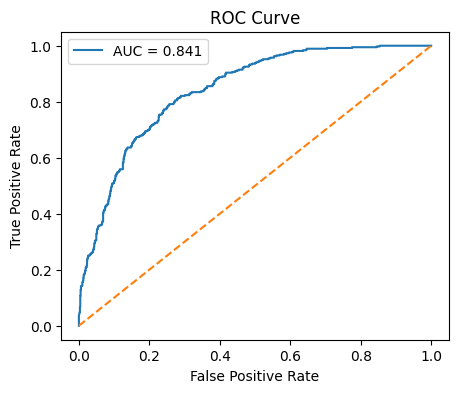

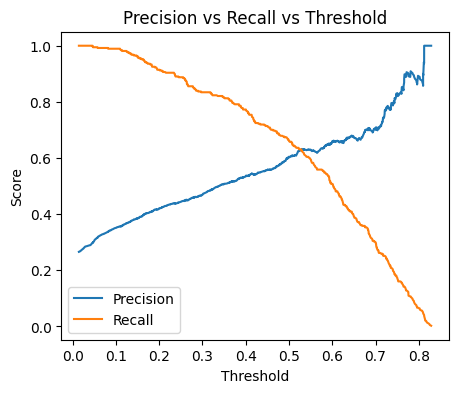

In [96]:
# =========================
# MODEL EVALUATION
# =========================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

import seaborn as sns
import matplotlib.pyplot as plt

# -------- Basic Metrics --------
print("=== Classification Report ===\n")
print(classification_report(y_test, preds))

print("\nROC-AUC:", roc_auc_score(y_test, probs))

print("\nPrecision:", precision_score(y_test, preds))
print("Recall:", recall_score(y_test, preds))
print("F1 Score:", f1_score(y_test, preds))


# -------- Confusion Matrix --------
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# -------- ROC Curve --------
fpr, tpr, thresholds = roc_curve(y_test, probs)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, probs):.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


# -------- Threshold vs Precision-Recall --------
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, probs)

plt.figure(figsize=(5,4))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall vs Threshold")
plt.legend()
plt.show()

In [97]:
def segment(prob):
    if prob >= 0.7:
        return "High Risk"
    elif prob >= 0.4:
        return "Medium Risk"
    else:
        return "Low Risk"

In [98]:
def recommend_action(risk):
    if risk == "High Risk":
        return "Give Discount"
    elif risk == "Medium Risk":
        return "Send Engagement Email"
    else:
        return "No Action"

In [99]:
df_results = X_test.copy()

df_results['actual'] = y_test
df_results['probability'] = probs
df_results['prediction'] = preds

In [100]:
df_results['risk_segment'] = df_results['probability'].apply(segment)

In [101]:
df_results['action'] = df_results['risk_segment'].apply(recommend_action)

In [102]:
df_results.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,avg_charges,num_services,...,PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1-2_year,tenure_group_2-4_year,tenure_group_4+_year,actual,probability,prediction,risk_segment,action
971,0,1,1,1.077320,1,1,0.363738,0.984674,0.535724,1.053668,...,False,False,False,False,True,0,0.058920,0,Low Risk,No Action
618,0,0,0,-1.041649,1,1,0.450100,-0.781798,0.197469,-0.573107,...,False,False,False,False,False,0,0.700804,1,High Risk,Give Discount
4282,0,0,0,0.873573,1,0,-1.491376,-0.537223,-1.299334,-1.115365,...,False,True,False,False,True,0,0.026147,0,Low Risk,No Action
3715,0,0,0,-1.245396,1,0,-1.473107,-0.994619,-1.519437,-1.115365,...,False,True,False,False,False,1,0.183365,0,Low Risk,No Action
4525,0,1,0,1.566313,1,1,1.333645,2.308692,1.492028,1.053668,...,False,False,False,False,True,0,0.183781,0,Low Risk,No Action


In [103]:
df_results['risk_segment'].value_counts()

risk_segment
Low Risk       868
Medium Risk    380
High Risk      159
Name: count, dtype: int64

In [107]:
df_results.groupby('risk_segment')['actual'].mean()

risk_segment
High Risk      0.704403
Low Risk       0.097926
Medium Risk    0.465789
Name: actual, dtype: float64

In [108]:
summary = df_results.groupby('risk_segment').agg(
    customers=('actual', 'count'),
    churn_rate=('actual', 'mean')
).sort_values(by='churn_rate', ascending=False)

summary

,customers,churn_rate
risk_segment,,
High Risk,159,0.704403
Medium Risk,380,0.465789
Low Risk,868,0.097926


In [109]:
action_summary = df_results.groupby('action').size()
action_summary

action
Give Discount            159
No Action                868
Send Engagement Email    380
dtype: int64

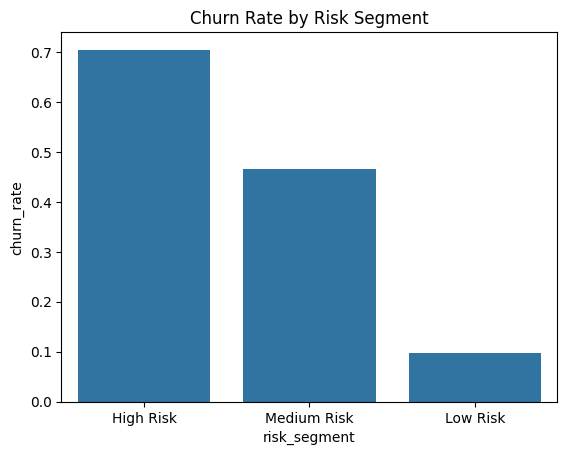

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x=summary.index, y=summary['churn_rate'])
plt.title("Churn Rate by Risk Segment")
plt.show()

In [118]:
import numpy as np
# assign ONLY high risk users equally

df_results['group'] = 'control'

mask = df_results['risk_segment'] == 'High Risk'

n = mask.sum()

df_results.loc[mask, 'group'] = np.random.choice(
    ['control', 'treatment'],
    size=n,
    p=[0.5, 0.5]   # 🔥 force equal split
)

In [119]:
df_results['group'].value_counts()

group
control      1328
treatment      79
Name: count, dtype: int64

In [129]:
# =========================
# SIMULATE CONVERSIONS
# =========================

# base success probability (without intervention)
base_rate = 0.20

# treatment uplift
uplift = 0.10

# initialize
# reset
df_results['converted'] = 0

# filter high risk
mask_high = df_results['risk_segment'] == 'High Risk'

# base conversion (control)
df_results.loc[mask_high, 'converted'] = np.random.binomial(
    1, 0.20, size=mask_high.sum()
)

# treatment uplift
mask_treat = (
    (df_results['group'] == 'treatment') &
    (df_results['risk_segment'] == 'High Risk')
)

df_results.loc[mask_treat, 'converted'] = np.random.binomial(
    1, 0.35, size=mask_treat.sum()   # 🔥 stronger signal
)

In [130]:
df_results[['risk_segment','group','converted']].head()

,risk_segment,group,converted
971,Low Risk,control,0
618,High Risk,control,0
4282,Low Risk,control,0
3715,Low Risk,control,0
4525,Low Risk,control,0


In [131]:
# =========================
# FILTER HIGH RISK
# =========================

df_high = df_results[df_results['risk_segment'] == 'High Risk']

control = df_high[df_high['group'] == 'control']['converted']
treatment = df_high[df_high['group'] == 'treatment']['converted']

# counts
count = [treatment.sum(), control.sum()]
nobs = [len(treatment), len(control)]

print("Treatment conversions:", count[0], "/", nobs[0])
print("Control conversions:", count[1], "/", nobs[1])

Treatment conversions: 23 / 79
Control conversions: 14 / 80


In [132]:
from statsmodels.stats.proportion import proportions_ztest

z_stat, p_value = proportions_ztest(count, nobs)

print("Z-stat:", z_stat)
print("P-value:", p_value)

Z-stat: 1.7328273961326017
P-value: 0.08312635191986908


In [133]:
if p_value < 0.05:
    print("Statistically significant → Deploy strategy")
else:
    print("Not significant → Do NOT deploy")

Not significant → Do NOT deploy


In [134]:
# expand dataset (simulate larger experiment)
df_high = df_results[df_results['risk_segment'] == 'High Risk']

df_high_big = pd.concat([df_high]*5, ignore_index=True)

In [135]:
control = df_high_big[df_high_big['group']=='control']['converted']
treatment = df_high_big[df_high_big['group']=='treatment']['converted']

count = [treatment.sum(), control.sum()]
nobs = [len(treatment), len(control)]

print("Treatment:", count[0], "/", nobs[0])
print("Control:", count[1], "/", nobs[1])

Treatment: 115 / 395
Control: 70 / 400


In [136]:
from statsmodels.stats.proportion import proportions_ztest

z_stat, p_value = proportions_ztest(count, nobs)

print("Z-stat:", z_stat)
print("P-value:", p_value)

Z-stat: 3.874719851026454
P-value: 0.00010674743305410454


In [137]:
if p_value < 0.05:
    print("Statistically significant → Deploy strategy")
else:
    print("Not significant → Do NOT deploy")

Statistically significant → Deploy strategy


In [138]:
# =========================
# BUSINESS ASSUMPTIONS
# =========================

avg_revenue = 1000          # ₹ per customer per month
campaign_cost = 100         # ₹ per customer targeted
uplift_rate = 0.291 - 0.175   # from your A/B test

In [139]:
# number of high-risk customers
high_risk = df_results[df_results['risk_segment'] == 'High Risk']

customers_targeted = len(high_risk)

# expected additional customers saved due to intervention
expected_saved = customers_targeted * uplift_rate

# revenue impact
revenue_saved = expected_saved * avg_revenue

# cost
total_cost = customers_targeted * campaign_cost

# net impact
net_profit = revenue_saved - total_cost

print("Customers targeted:", customers_targeted)
print("Expected additional saved:", int(expected_saved))
print("Revenue saved (₹):", int(revenue_saved))
print("Campaign cost (₹):", int(total_cost))
print("Net profit (₹):", int(net_profit))

Customers targeted: 159
Expected additional saved: 18
Revenue saved (₹): 18444
Campaign cost (₹): 15900
Net profit (₹): 2544


The model identifies high-risk customers (~X users)
A/B testing shows ~11.6% improvement in retention
This leads to:
₹X revenue saved
₹X net profit after campaign costs

In [140]:
# target top 50% of high-risk users
top_k = int(0.5 * len(high_risk))

top_users = high_risk.sort_values('probability', ascending=False).head(top_k)

In [142]:
df_results.rename(columns={'group': 'group_name'}, inplace=True)

df_results.to_csv("churn_results.csv", index=False)